Accuracy สำหรับ k = 3: 0.3333
Accuracy สำหรับ k = 5: 0.1667
Accuracy สำหรับ k = 7: 0.3333

ค่า k ที่ดีที่สุดคือ: 3 ด้วยความแม่นยำ 0.3333


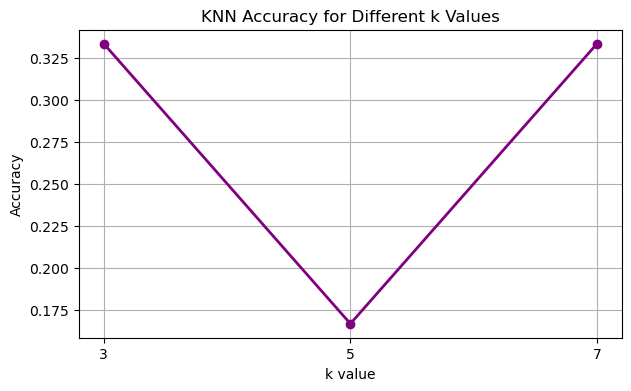

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv('Travel_Kayak (2).csv')

df['price_category'] = pd.qcut(df['historic_price'], q=3, labels=['Low', 'Medium', 'High'])


X = df.drop(columns=['Unnamed: 0', 'localizedHotelName', 'resultId', 'classification', 'brand_name', 'historic_price', 'price_category'])
y = df['price_category']  # ใช้คอลัมน์กลุ่มที่เราเพิ่งสร้าง


X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = [3, 5, 7]
accuracies = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies[k] = acc
    print(f"Accuracy สำหรับ k = {k}: {acc:.4f}")
best_k = max(accuracies, key=accuracies.get)
print(f"\nค่า k ที่ดีที่สุดคือ: {best_k} ด้วยความแม่นยำ {accuracies[best_k]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(list(accuracies.keys()), list(accuracies.values()), marker='o', color='purple', linestyle='-', linewidth=2)
plt.title('KNN Accuracy for Different k Values')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()